In [1]:
import pickle

In [4]:
import numpy as np

np.load('4_PRE.npy')[:45]

array([[1341, 1495],
       [1122, 1675],
       [1143, 1902],
       [1242, 1780],
       [1517, 1713],
       [2027, 1461],
       [1905, 1754],
       [2025, 2125],
       [1945, 2700],
       [1938, 2773],
       [1978, 2585],
       [1513, 2009],
       [2065, 2069],
       [1555, 2071],
       [1400, 1905],
       [1191, 1844],
       [1116, 2181],
       [1243, 2438],
       [1867, 2826],
       [2098, 2401],
       [1982, 2183],
       [2084, 2397],
       [1971, 2560],
       [1938, 2372],
       [1690, 2284],
       [1711, 2130],
       [1715, 2350],
       [1691, 2481],
       [2095, 1410],
       [2076, 1521],
       [2219, 1814],
       [2298, 1982],
       [2242, 2059],
       [2160, 2102],
       [2156, 2118],
       [2206, 2223],
       [2241, 2289],
       [2180, 2358],
       [2131, 2350],
       [2026, 2373],
       [2168, 2361],
       [2231, 2444],
       [2147, 2547],
       [2092, 2686],
       [1868, 2880]], dtype=uint32)

In [2]:
with open('dental_train.pickle', 'rb') as f:
    A = pickle.load(f)

In [3]:
for i in range(30):
    print(A['train'][i].keys())

dict_keys(['SNU/197', 'PRE', 'PRE_B'])
dict_keys(['SNU/186', 'A', 'A_B'])
dict_keys(['SNU/17', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/123', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/175', 'A', 'A_B'])
dict_keys(['SNU/63', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/291', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/217', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/100', 'A', 'A_B'])
dict_keys(['SNU/178', 'A', 'A_B'])
dict_keys(['SNU/219', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/268', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/61', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/346', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/396', 'A', 'A_B'])
dict_keys(['SNU/309', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/432', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/387', 'A', 'A_B'])
dict_keys(['SNU/275', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/225', 'A', 'A_B'])
dict_keys(['SNU/249', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_keys(['SNU/366', 'A', 'PRE', 'A_B', 'PRE_B'])
dict_

In [20]:
A['train'][2]['A_B'][:10]

[[1213, 428],
 [963, 647],
 [966, 867],
 [1100, 804],
 [1371, 657],
 [1859, 381],
 [1748, 715],
 [1876, 1080],
 [1792, 1619],
 [1786, 1706]]

In [21]:
A['train'][2]['PRE_B'][:10]

[[1336, 1464],
 [1072, 1666],
 [1060, 1886],
 [1198, 1831],
 [1479, 1703],
 [1983, 1460],
 [1850, 1786],
 [1954, 2158],
 [1835, 2691],
 [1823, 2777]]

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
A = [i for i in range(100)]
B = [j for j in range(100)]

In [27]:
train_A, valid_A, train_B, valid_B = train_test_split(A, B)

In [31]:
train_B

[70,
 86,
 87,
 85,
 50,
 18,
 4,
 80,
 34,
 31,
 51,
 42,
 20,
 13,
 73,
 19,
 39,
 78,
 15,
 59,
 43,
 94,
 64,
 58,
 90,
 21,
 62,
 84,
 79,
 7,
 30,
 96,
 5,
 11,
 44,
 32,
 6,
 27,
 83,
 71,
 74,
 68,
 3,
 98,
 12,
 65,
 67,
 89,
 36,
 45,
 53,
 81,
 8,
 60,
 9,
 95,
 52,
 69,
 1,
 41,
 55,
 29,
 75,
 14,
 17,
 72,
 56,
 26,
 0,
 49,
 76,
 28,
 38,
 22,
 92]

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def img_crop(pre_image_paths, post_image_paths, pre_points, post_points, train_size):
    
    
    post_xs = post_points[:,0]
    post_ys = post_points[:,1]
    min_x = int(np.min(post_xs))
    min_y = int(np.min(post_ys))
    max_x = int(np.max(post_xs))
    max_y = int(np.max(post_ys))
    
    if post_image_paths.split('/')[-1].split('.')[-1] == 'png':
        post_image = cv2.imread(post_image_paths)
    elif post_image_paths.split('/')[-1].split('.')[-1] == 'dcm':
        post_image = pydicom.dcmread(post_image_paths).pixel_array
    
    post_crop_image =  post_image[min_y - int(post_image.shape[0]/10) :post_image.shape[0],  min_x-int(post_image.shape[1]/10) :post_image.shape[1]]
    post_points[:,0] -= (min_x - int(post_image.shape[1]/10))
    post_points[:,1] -= (min_y - int(post_image.shape[0]/10))
    
    pre_xs = pre_points[:,0]
    pre_ys = pre_points[:,1]
    min_x = int(np.min(pre_xs))
    min_y = int(np.min(pre_ys))
    max_x = int(np.max(pre_xs))
    max_y = int(np.max(pre_ys))
    #####################################################################
    #이미지, 계측점 크롭처리 부분
    #####################################################################
    
    if pre_image_paths.split('/')[-1].split('.')[-1] == 'png':
        pre_image = cv2.imread(pre_image_paths)
    elif pre_image_paths.split('/')[-1].split('.')[-1] == 'dcm':
        pre_image = pydicom.dcmread(pre_image_paths).pixel_array

    
    pre_crop_image  =  pre_image[min_y  - int(pre_image.shape[0]/10)  :pre_image.shape[0],   min_x-int(pre_image.shape[1]/10)  :pre_image.shape[1]]

    pre_points[:,0] -= (min_x - int(pre_image.shape[1]/10))
    pre_points[:,1] -= (min_y - int(pre_image.shape[0]/10))

    crop_pre_points = pre_points
    crop_post_points = post_points
    #이미지 학습할때 크기로 변경
    if(pre_crop_image.shape[0] > pre_crop_image.shape[1]):
        bigger_axis = pre_crop_image.shape[0]
    else:
        bigger_axis = pre_crop_image.shape[1]
        
    resize_factor = train_size[0] / bigger_axis
    
    pre_image = cv2.resize(pre_crop_image, dsize=(0, 0), fx=resize_factor, fy=resize_factor, interpolation=cv2.INTER_LINEAR)
    post_image = cv2.resize(post_crop_image, dsize=(0, 0), fx=resize_factor, fy=resize_factor, interpolation=cv2.INTER_LINEAR)
    

    pre_points = crop_pre_points*resize_factor
    post_points = crop_post_points*resize_factor
    
    pre_pading_image = np.zeros((train_size[0],train_size[1],3),dtype=np.uint8)
    pre_pading_image[0:pre_image.shape[0],0:pre_image.shape[1]] = pre_image
    
    post_pading_image = np.zeros((train_size[0],train_size[1],3),dtype=np.uint8)
    post_pading_image[0:post_image.shape[0],0:post_image.shape[1]] = post_image
    
    return pre_pading_image, post_pading_image, pre_points, post_points

In [151]:
def img_crop(image_paths, points, train_size):
    pre_xs = points[:,0]
    pre_ys = points[:,1]
    min_x = int(np.min(pre_xs))
    min_y = int(np.min(pre_ys))
    max_x = int(np.max(pre_xs))
    max_y = int(np.max(pre_ys))
    #####################################################################
    #이미지, 계측점 크롭처리 부분
    #####################################################################
    if image_paths.split('/')[-1].split('.')[-1] == 'png':
        image = cv2.imread(image_paths)
    elif image_paths.split('/')[-1].split('.')[-1] == 'dcm':
        image = pydicom.dcmread(image_paths).pixel_array
    Crop_image =  image[min_y - int(image.shape[0]/10) :image.shape[0],  min_x-int(image.shape[1]/10):image.shape[1]]
    points[:,0] -= (min_x - int(image.shape[1]/10))
    points[:,1] -= (min_y - int(image.shape[0]/10))

    crop_points = points
    #이미지 학습할때 크기로 변경
    print(Crop_image.shape)
    if(Crop_image.shape[0] > Crop_image.shape[1]):
        bigger_axis = Crop_image.shape[0]
    else:
        bigger_axis = Crop_image.shape[1]
    resize_factor = train_size[0] / bigger_axis
    image = cv2.resize(Crop_image, dsize=(0, 0), fx=resize_factor, fy=resize_factor, interpolation=cv2.INTER_LINEAR)
    points = crop_points*resize_factor
    
    pading_image = np.zeros((train_size[0],train_size[1],3),dtype=np.uint8)
    pading_image[0:image.shape[0],0:image.shape[1]] = image
    return pading_image/255, points

In [ ]:
def img_crop(image_paths, points, train_size, transform = False):

    distance = []
    pre_points = np.array(pre_points[index])
    post_points = np.array(post_points[index][:45])
#         patient_info = np.array(self.patient_infos[index])

    #경조직에서 최대 최소점 가져오기
    pre_xs = pre_points[:,0]
    pre_ys = pre_points[:,1]
    min_x = int(np.min(pre_xs))
    min_y = int(np.min(pre_ys))
    max_x = int(np.max(pre_xs))
    max_y = int(np.max(pre_ys))

    #####################################################################
    #이미지, 계측점 크롭처리 부분
    #####################################################################
    image_path = self.image_paths[index]
    image = cv2.imread(image_path)

    Crop_image =  image[min_y - int(image.shape[0]/10) :image.shape[0],  min_x-int(image.shape[1]/10):image.shape[1]]

    pre_points[:,0] -= (min_x - int(image.shape[1]/10))
    pre_points[:,1] -= (min_y - int(image.shape[0]/10))
    post_points[:,0] -= (min_x - int(image.shape[1]/10))
    post_points[:,1] -= (min_y - int(image.shape[0]/10))

    crop_pre_points = pre_points
    crop_post_points = post_points

    #이미지 학습할때 크기로 변경
    if(Crop_image.shape[0] > Crop_image.shape[1]):
        bigger_axis = Crop_image.shape[0]
    else:
        bigger_axis = Crop_image.shape[1]

    resize_factor = self.train_size[0] / bigger_axis

    image = cv2.resize(Crop_image, dsize=(0, 0), fx=resize_factor, fy=resize_factor, interpolation=cv2.INTER_LINEAR)
    pre_points = crop_pre_points*resize_factor
    post_points = crop_post_points*resize_factor

    pading_image = np.zeros((self.train_size[0],self.train_size[1],3),dtype=np.uint8)
    pading_image[0:image.shape[0],0:image.shape[1]] = image

    #process 를 편하게 하기 위해서 우선 agumentation 부터 적용
    sample = {'image': pading_image, 'pre_landmarks': pre_points, 'post_landmarks': post_points}

    if transform:
        sample = transform(sample)

    image = sample['image']/255.
    pre_points = sample['pre_landmarks']
    post_points = sample['post_landmarks']
    pre_points = pre_points.astype("float")
    #########################################################################
    #이동량 구하기
    temp_move = post_points - pre_points #이동량 예측할때
    move = temp_move[self.out_point_idx] # 연조직버전으로 변경 필요 --> (self.out_point_idx 사용)
    #####################################################################################
    #여기서 거리구하고 특정 거리 이내에 데이터는 거리량 죽이기. for문에 len(move) 사용
    for i in range(len(move)):# 연조직버전으로 변경 필요
        distance.append(np.linalg.norm(move[i]))
    distance = np.array(distance)
    #####################################################################################

    Graph_input = copy.deepcopy(pre_points)
    #2.패치의 길이로 정규화
    Graph_input[:,0] /= self.train_size[0]
    Graph_input[:,1] /= self.train_size[1]
    Graph_input = Graph_input.tolist()
    for i in range(len(Graph_input)):
        for j in range(len(Graph_input)):
            x_dis = (pre_points[i][0] - pre_points[j][0]) / self.train_size[0]
            y_dis = (pre_points[i][1] - pre_points[j][1]) / self.train_size[0]
            Graph_input[i].append(x_dis)
            Graph_input[i].append(y_dis)

    Graph_input = np.array(Graph_input)
    move = np.array(move)
    #여기까지 좌표, 거리 각도 다 구해놓음
    ############################################################################

    # B에서 예측점 선택
    post_points = post_points[self.out_point_idx]

    #        0         1         2       3           4            5            6               7
    return image, Graph_input, move, distance, resize_factor, pre_points, post_points#, patient_info

In [158]:
import torch
class Dataset_Image_Point(torch.utils.data.Dataset):
    def __init__(self, input_data_pickle, mode = "train", transform=None, train_size = (512,512)):
        self.ROOT = "/mnt/nas125/dental/new_total_research/post_processing_image/total"
        #                                       경조직                              |                   연조직
#         self.out_point_idx = [7,8,9,10,11,12,13,16,17,18,19,20,21,22,23,24,25,26,27, 31,32,33,34,35,36,37,38,39,40,41,42,43,44] <-- 전체

        #                                       경조직   |                   연조직
        self.out_point_idx = [7,8,9,10,12,18,19,20,21,22, 31,32,33,34,35,36,37,38,39,40,41,42,43,44]
        with open(input_data_pickle, 'rb') as f:
            self.input_datas = pickle.load(f)[mode]
        self.image_paths = []
        self.pre_points = []
        self.post_points = []
#         self.patient_infos = self.input_datas[:,???]

        for patient in self.input_datas:
            patient_keys=list(patient.keys())
            dir_path=patient_keys[0]
            patient_number = dir_path.split('/')[-1]
            if len(patient.keys()) == 5:
                self.image_paths.append(self.ROOT+'/'+dir_path+"/"+patient_number+"_A.png")
                self.image_paths.append(self.ROOT+'/'+dir_path+"/"+patient_number+"_PRE.png")
                self.pre_points.append(patient['A'])
                self.pre_points.append(patient['PRE'])
                self.post_points.append(patient['A_B'])
                self.post_points.append(patient['PRE_B'])
            elif len(patient.keys()) == 3:
                if patient_keys[1] == "A":
                    self.image_paths.append(self.ROOT+'/'+dir_path+"/"+patient_number+"_A.png")
                    self.pre_points.append(patient['A'])
                    self.post_points.append(patient['A_B'])
                elif patient_keys[1] == "PRE":
                    self.image_paths.append(self.ROOT+'/'+dir_path+"/"+patient_number+"_PRE.png")
                    self.pre_points.append(patient['PRE'])
                    self.post_points.append(patient['PRE_B'])
                else:
                    raise Exception("dict key error")
            else:
                raise Exception("len(patient.keys()) != 5 or 3")

        self.mode = mode
        self.train_size = train_size
        
        self.transform = transform
        self.num_of_land = 33 #--> 연조직까지 포함이라 숫자 바뀜

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        distance = []
        pre_points = np.array(self.pre_points[index])
        post_points = np.array(self.post_points[index][:45])
#         patient_info = np.array(self.patient_infos[index])

        #경조직에서 최대 최소점 가져오기
        pre_xs = pre_points[:,0]
        pre_ys = pre_points[:,1]
        min_x = int(np.min(pre_xs))
        min_y = int(np.min(pre_ys))
        max_x = int(np.max(pre_xs))
        max_y = int(np.max(pre_ys))

        #####################################################################
        #이미지, 계측점 크롭처리 부분
        #####################################################################
        image_path = self.image_paths[index]
        image = cv2.imread(image_path)
        
        Crop_image =  image[min_y - int(image.shape[0]/10) :image.shape[0],  min_x-int(image.shape[1]/10):image.shape[1]]
        
        pre_points[:,0] -= (min_x - int(image.shape[1]/10))
        pre_points[:,1] -= (min_y - int(image.shape[0]/10))
        post_points[:,0] -= (min_x - int(image.shape[1]/10))
        post_points[:,1] -= (min_y - int(image.shape[0]/10))

        crop_pre_points = pre_points
        crop_post_points = post_points

        #이미지 학습할때 크기로 변경
        if(Crop_image.shape[0] > Crop_image.shape[1]):
            bigger_axis = Crop_image.shape[0]
        else:
            bigger_axis = Crop_image.shape[1]

        resize_factor = self.train_size[0] / bigger_axis

        image = cv2.resize(Crop_image, dsize=(0, 0), fx=resize_factor, fy=resize_factor, interpolation=cv2.INTER_LINEAR)
        pre_points = crop_pre_points*resize_factor
        post_points = crop_post_points*resize_factor

        pading_image = np.zeros((self.train_size[0],self.train_size[1],3),dtype=np.uint8)
        pading_image[0:image.shape[0],0:image.shape[1]] = image

        #process 를 편하게 하기 위해서 우선 agumentation 부터 적용
        sample = {'image': pading_image, 'pre_landmarks': pre_points, 'post_landmarks': post_points}

        if self.transform:
            sample = self.transform(sample)

        image = sample['image']/255.
        pre_points = sample['pre_landmarks']
        post_points = sample['post_landmarks']
        pre_points = pre_points.astype("float")
        #########################################################################
        #이동량 구하기
        temp_move = post_points - pre_points #이동량 예측할때
        move = temp_move[self.out_point_idx] # 연조직버전으로 변경 필요 --> (self.out_point_idx 사용)
        #####################################################################################
        #여기서 거리구하고 특정 거리 이내에 데이터는 거리량 죽이기. for문에 len(move) 사용
        for i in range(len(move)):# 연조직버전으로 변경 필요
            distance.append(np.linalg.norm(move[i]))
        distance = np.array(distance)
        #####################################################################################

        Graph_input = copy.deepcopy(pre_points)
        #2.패치의 길이로 정규화
        Graph_input[:,0] /= self.train_size[0]
        Graph_input[:,1] /= self.train_size[1]
        Graph_input = Graph_input.tolist()
        for i in range(len(Graph_input)):
            for j in range(len(Graph_input)):
                x_dis = (pre_points[i][0] - pre_points[j][0]) / self.train_size[0]
                y_dis = (pre_points[i][1] - pre_points[j][1]) / self.train_size[0]
                Graph_input[i].append(x_dis)
                Graph_input[i].append(y_dis)
                
        Graph_input = np.array(Graph_input)
        move = np.array(move)
        #여기까지 좌표, 거리 각도 다 구해놓음
        ############################################################################
        
        # B에서 예측점 선택
        post_points = post_points[self.out_point_idx]
        
        #        0         1         2       3           4            5            6               7
        return image, Graph_input, move, distance, resize_factor, pre_points, post_points#, patient_info

In [161]:
A = Dataset_Image_Point_Test(input_data_pickle = 'dental_train.pickle')

AttributeError: 'str' object has no attribute 'keys'

In [171]:
with open('dental_train.pickle', 'rb') as f:
    input_datas = pickle.load(f)['train']

In [175]:
patient_keys=list(patient.keys())

In [176]:
patient_keys

['KBU/1', 'A', 'PRE', 'A_B', 'PRE_B']

In [174]:
patient.keys()

dict_keys(['KBU/1', 'A', 'PRE', 'A_B', 'PRE_B'])

In [173]:
for patient in input_datas:
    print(patient)


{'SNU/197': ['PRE', 'B'], 'PRE': [[1246, 1369], [1040, 1542], [997, 1761], [1161, 1670], [1431, 1578], [1953, 1285], [1848, 1604], [1949, 1930], [2033, 2519], [2047, 2592], [2015, 2401], [1481, 1851], [1952, 1856], [1526, 1945], [1354, 1823], [1112, 1675], [1189, 2045], [1323, 2230], [1972, 2654], [2055, 2192], [1936, 1999], [2062, 2191], [2001, 2387], [1963, 2185], [1634, 2088], [1691, 1951], [1699, 2182], [1677, 2324], [2047, 1131], [2015, 1384], [2107, 1606], [2222, 1789], [2166, 1874], [2080, 1910], [2078, 1925], [2097, 1961], [2170, 2035], [2116, 2118], [2076, 2111], [2092, 2199], [2143, 2157], [2218, 2242], [2165, 2346], [2170, 2547], [1966, 2714]], 'PRE_B': [[1246, 1369], [1041, 1534], [992, 1737], [1154, 1666], [1426, 1574], [1951, 1285], [1846, 1608], [1944, 1928], [1982, 2419], [1978, 2508], [1959, 2324], [1478, 1827], [1969, 1864], [1485, 1946], [1340, 1805], [1103, 1674], [1153, 2024], [1185, 2104], [1905, 2563], [2030, 2180], [1910, 1985], [1986, 2150], [1932, 2330], [1873

In [165]:
input_datas

KeyError: 0

In [152]:
pre, pre_pt = img_crop('SNU/4_A.png', A_landmark, (512, 512))
pos, pos_pt = img_crop('SNU/4_B.png', B_landmark, (512, 512))

(2000, 2510, 3)
(3014, 2504, 3)


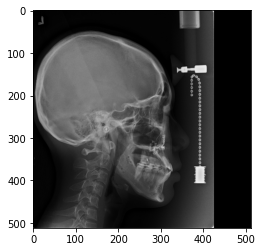

In [153]:
plt.imshow(pos)

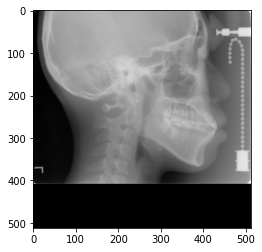

In [154]:
plt.imshow(pre)

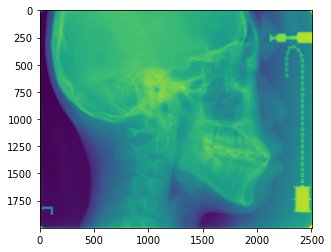

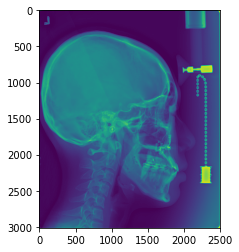

In [155]:
A = np.array(Image.open('SNU/4_A.png'))
B = np.array(Image.open('SNU/4_B.png'))

plt.imshow(A)
plt.show()
plt.imshow(B)
plt.show()